# Lab 3: Exploratory Data Analysis (EDA)

## EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

What does the data look like?

Are there missing values?

What patterns exist?

Are there relationships between variables?

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
#Loading Dataset
df = pd.read_csv("Retail_Store_Sales.csv")
df.head(7)

,Customer ID,City,Category,Purchase Date,Quantity,Unit Price,Total Amount,Month
0,4174,Makkah,Clothing,2023-01-01,9,413.17,3718.53,2023-01
1,4507,Riyadh,Groceries,2023-01-02,1,282.62,282.62,2023-01
2,1860,Jeddah,Groceries,2023-01-03,1,39.58,39.58,2023-01
3,2294,Makkah,Groceries,2023-01-04,9,171.20,1540.80,2023-01
4,2130,Jeddah,Sports,2023-01-05,6,296.26,1777.56,2023-01
5,2095,Khobar,Sports,2023-01-06,4,476.29,1905.16,2023-01
6,4772,Khobar,Sports,2023-01-07,7,432.38,3026.66,2023-01


The dataset consists of retail sales transactions.
Each row represents a single purchase made by a customer.

In [4]:
#Data Type of Columns
df.dtypes

Customer ID        int64
City              object
Category          object
Purchase Date     object
Quantity           int64
Unit Price       float64
Total Amount     float64
Month             object
dtype: object

The dataset contains numerical, categorical, and date variables.

In [5]:
#Convert Date Column
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df.dtypes

Customer ID               int64
City                     object
Category                 object
Purchase Date    datetime64[ns]
Quantity                  int64
Unit Price              float64
Total Amount            float64
Month                    object
dtype: object

The purchase date has been converted to datetime format to enable time-based analysis.

In [6]:
#Check Missing Values
print(df.isna().sum())

Customer ID      0
City             0
Category         0
Purchase Date    0
Quantity         0
Unit Price       0
Total Amount     0
Month            0
dtype: int64


There are no missing values in the dataset.

In [7]:
#Check Duplicate Rows
df.duplicated()[df.duplicated() == True]

Series([], dtype: bool)

No duplicate records were found.

In [8]:
#Number of Rows and Columns
print("Shape (rows, columns): ", df.shape, "\n")
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Shape (rows, columns):  (3000, 8) 

Number of rows:  3000
Number of columns:  8


The dataset contains 3000 rows and multiple useful features suitable for analysis.

In [9]:
#Descriptive Summary Statistics
df.describe(include="all")

,Customer ID,City,Category,Purchase Date,Quantity,Unit Price,Total Amount,Month
count,3000.000000,3000,3000,3000,3000.00000,3000.000000,3000.000000,3000
unique,NaN,5,5,NaN,NaN,NaN,NaN,99
top,NaN,Makkah,Clothing,NaN,NaN,NaN,NaN,2023-01
freq,NaN,614,662,NaN,NaN,NaN,NaN,31
mean,3003.963333,NaN,NaN,2027-02-08 12:00:00,5.02100,261.885020,1300.370020,NaN
min,1001.000000,NaN,NaN,2023-01-01 00:00:00,1.00000,20.030000,22.710000,NaN
25%,1995.750000,NaN,NaN,2025-01-19 18:00:00,3.00000,142.170000,447.660000,NaN
50%,2996.000000,NaN,NaN,2027-02-08 12:00:00,5.00000,260.845000,1008.465000,NaN
75%,4025.750000,NaN,NaN,2029-02-27 06:00:00,7.00000,383.385000,1924.070000,NaN
max,4999.000000,NaN,NaN,2031-03-19 00:00:00,9.00000,499.840000,4471.380000,NaN


The summary statistics show central tendency and spread for numerical features.

# Univariate Analysis

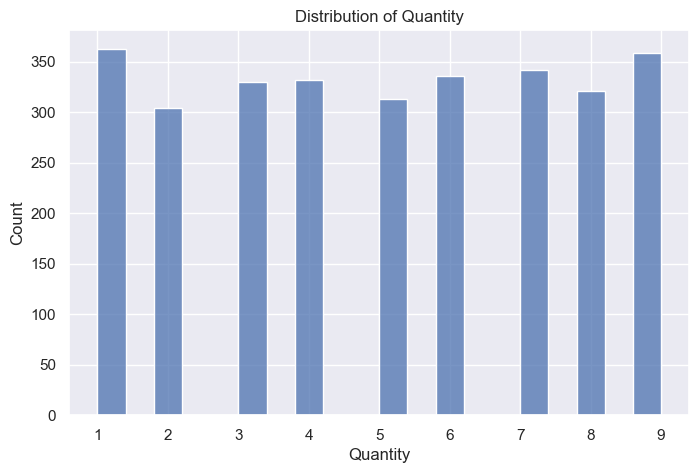

In [10]:
#Distribution of Quantity
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=20)
plt.title("Distribution of Quantity")
plt.show()

Most customers purchase small quantities per transaction.

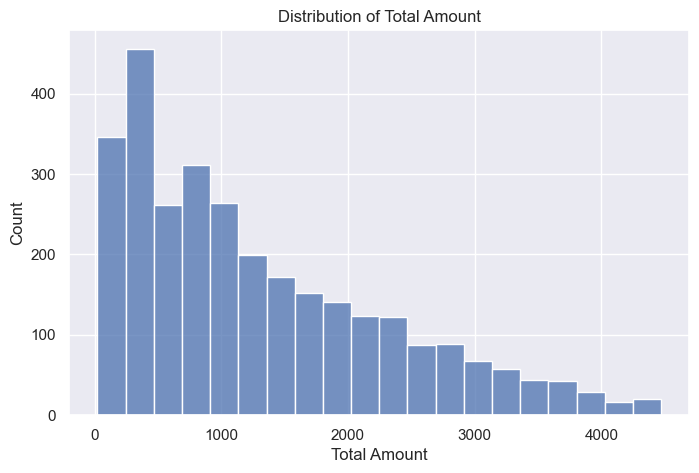

In [12]:
#Distribution of Total Amount 
plt.figure(figsize=(8,5))
sns.histplot(df["Total Amount"], bins=20)
plt.title("Distribution of Total Amount")
plt.show()

The revenue distribution is slightly right-skewed, indicating some high-value purchases.

# Bivariate Analysis

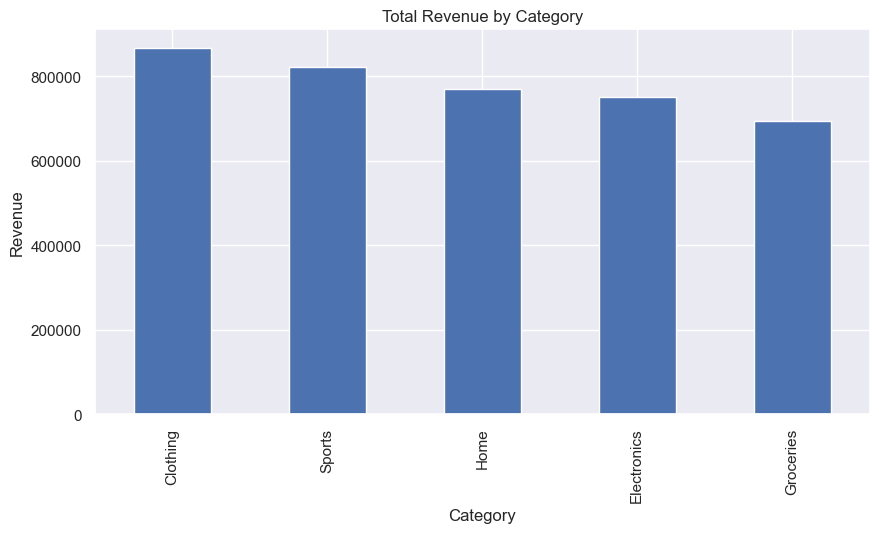

In [14]:
#Revenue by Category
category_revenue = df.groupby("Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_revenue.plot(kind="bar")
plt.title("Total Revenue by Category")
plt.ylabel("Revenue")
plt.show()

Certain product categories generate significantly higher revenue.

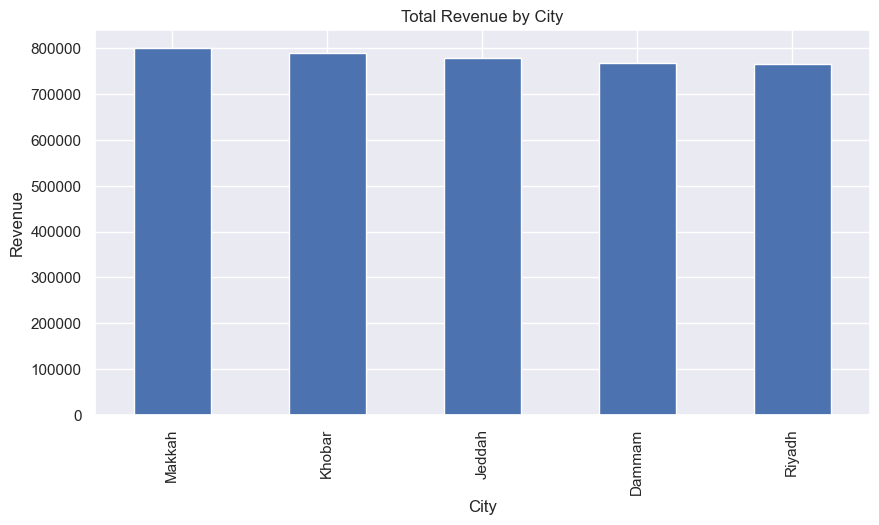

In [15]:
#Revenue by City
city_revenue = df.groupby("City")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_revenue.plot(kind="bar")
plt.title("Total Revenue by City")
plt.ylabel("Revenue")
plt.show()

Sales performance differs across cities.

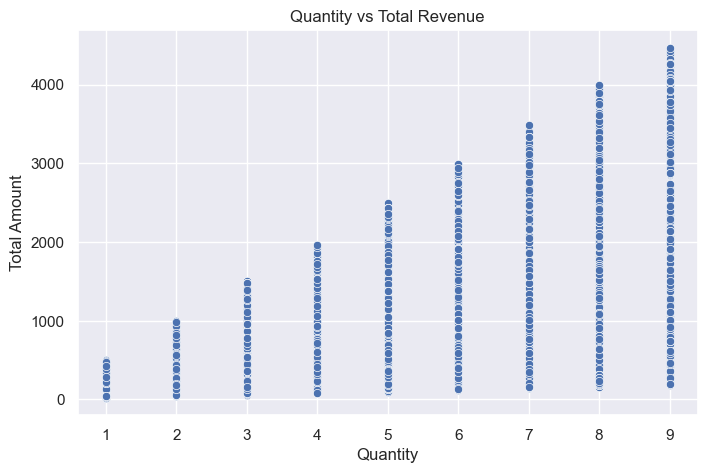

In [18]:
#Quantity vs Revenue Relationship  
plt.figure(figsize=(8,5))
sns.scatterplot(x="Quantity", y="Total Amount", data=df)
plt.title("Quantity vs Total Revenue")
plt.show()

There is a positive relationship between quantity purchased and total revenue.

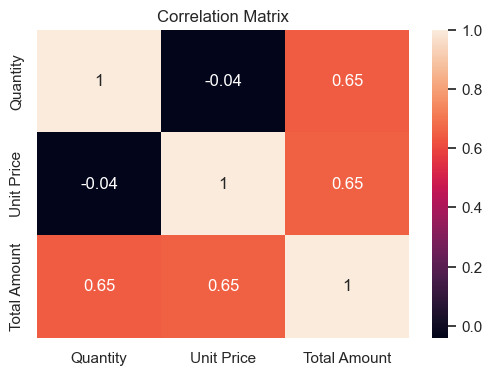

In [19]:
#Correlation Matrix
plt.figure(figsize=(6,4))
sns.heatmap(df[["Quantity", "Unit Price", "Total Amount"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Total Amount has strong positive correlation with Quantity and Unit Price.

# Time-Based Analysis

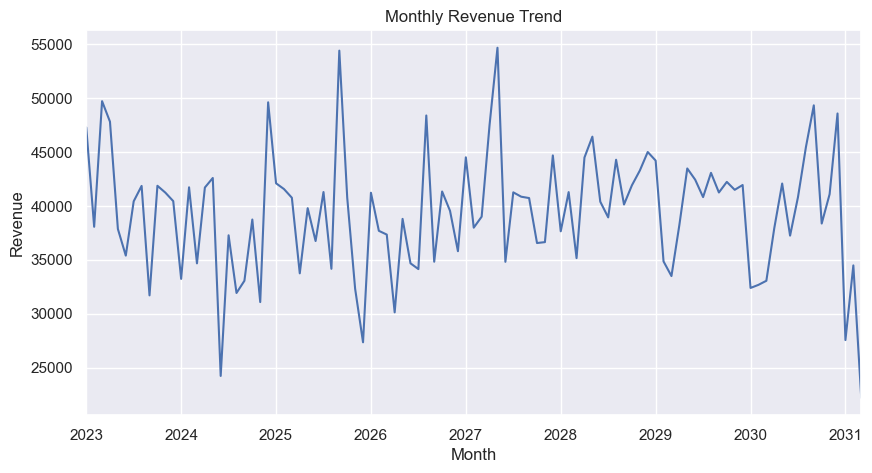

In [20]:
#Monthly Revenue Trend
df["Month"] = df["Purchase Date"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

The monthly trend shows fluctuations over time, which may indicate seasonal patterns.